## Mini-Projeto Avaliativo — Módulo 2
### Desenvolvimento de IA para Análise Preditiva — Classificação de dígitos manuscritos (MNIST)

**Autor:** Lindomar Andrade Gertrudes

Este notebook está segmentado nas Fases e Desafios exigidos no enunciado. Cada seção
tem uma célula de texto justificando as decisões técnicas e as células de código
correspondentes.



## Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

**O que esta fase precisa entregar (critério 4):**
1. Carregar o MNIST **(fetch_openml('mnist_784'))**
2. Exibir a dimensionalidade de **X** e **y**
3. Comprovar a distribuição das classes (balanceamento dos dígitos 0–9)
4. Grade visual de no mínimo 2×5 com um exemplo de cada dígito + rótulo
5. Célula de texto interpretando a estrutura dos dados (escala 0–255, imagem 28×28 → vetor de 784)


#### 1.1 - Célula de importações

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml

### 1.2 - Carregamento do dataset

In [2]:
# carregando o MNIST com fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
# Aqui o y volta como STRING buscando converter para inteiro (ex: y = y.astype(np.uint8))
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target
y = y.astype(np.uint8)  

### 1.3 - Dimensionalidade dos dados

In [3]:
# imprimindo X.shape, y.shape, X.dtype, X.min(), X.max()

print(X.shape, y.shape, X.dtype, X.min(), X.max())

(70000, 784) (70000,) int64 0 255


### Descrevendo a dimensionalidade dos dados:

- O dataset tem 70.000 imagens; cada uma é descrita por 784 valores.
- Esses 784 vêm de imagens 28×28 pixels achatadas em vetor (28*28 = 784).
- y tem 70.000 rótulos, um dígito de 0 a 9 por imagem.
- Os pixels vão de 0 (preto) a 255 (branco), em 8 bits, ainda sem normalização.

### 1.4 - Distribuição das classes

0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64


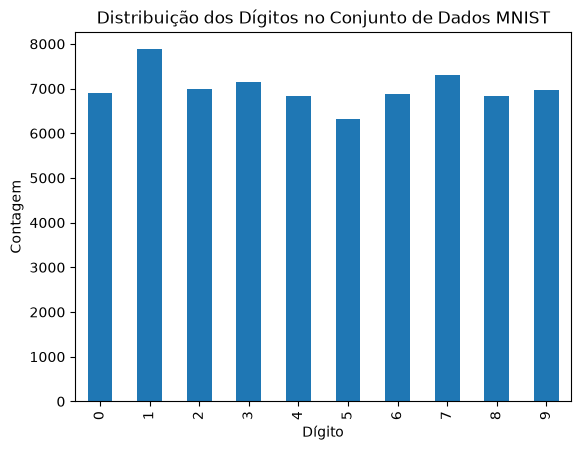

In [4]:
# Aqui vamos calcular a frequência de cada classe (dígitos de 0 a 9) no dataset

# e depois vamos plotar um gráfico de barras com a contagem total de amostras por dígito.

pd.Series(y).value_counts().sort_index().plot(kind='bar')
print(pd.Series(y).value_counts().sort_index())
plt.xlabel('Dígito')
plt.ylabel('Contagem')
plt.title('Distribuição dos Dígitos no Conjunto de Dados MNIST')
plt.show()

#### Breves observações até aqui:
* O dataset está balanceado. A diferença entre a classe mais e menos frequente é de ~20%, o que caracteriza um dataset balanceado. Por isso a acurácia global é uma métrica confiável neste problema; ainda assim vamos acompanhar precision/recall/F1 por classe.

### 1.5 - Criando uma grade visual dos dígitos (mínimo 2×5)

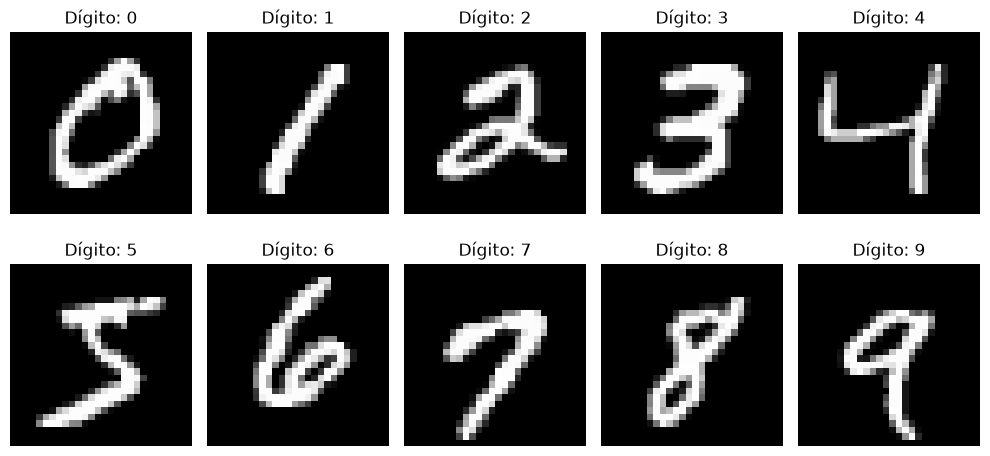

In [5]:
# Aqui vamos gerar um painel 2x5 contendo a primeira ocorrência de cada dígito (0 a 9).

# Depois vamos reformatar os dados para matrizes 28x28 e exibir em escala de cinza com seus respectivos rótulos.

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for d in range(10):
    idx = np.where(y == d)[0][0]  # Primeiro índice onde y == d
    img = X[idx].reshape(28, 28)  # Reshape para 28x28
    ax = axes[d // 5, d % 5]  # Seleciona o subplot correto
    ax.imshow(img, cmap='gray')  # Plota a imagem em escala de cinza
    ax.axis('off')  # Desliga os eixos
    ax.set_title(f'Dígito: {d}')  # Define o título como o dígito correspondente
plt.tight_layout()
plt.show()  

### 1.6 - Interpretação da estrutura dos dados acima:

**1. Escala de pixel 0–255:**

* Cada quadradinho (pixel) guarda um número entre 0 e 255 para mostrar o seu brilho: 0 é o preto absoluto, 
255 é o branco puro e os números do meio são os vários tons de cinza (do mais escuro ao mais claro). Como só usamos essa variação de brilho, a imagem tem apenas 1 canal (escala de cinza). É diferente de uma foto colorida comum, que precisa misturar 3 canais de cores (Vermelho, Verde e Azul) para formar a imagem.

**2. De 28×28 para 784 (flatten):**

* Imagine que a imagem original é um quadrado formado por um quadriculado de 28 fileiras de altura por 28 fileiras de largura, somando 784 quadradinhos (pixels). Para que modelos tradicionais de inteligência artificial consigam ler essa imagem, fazemos o seguinte, recortamos linha por linha da imagem e colocamos todas em uma única fila reta. Isso transforma a imagem em uma linha comprida com 784 pontos de informação. Cada ponto dessa fila indica apenas o quão claro ou escuro é aquele ponto específico da imagem..

**3. O que se perde:**

* Quando colocamos todos os quadradinhos em uma única fila (o chamado flatten), a imagem perde o seu "mapa" e o modelo "esquece" o formato original, ele não percebe mais quais pedacinhos ficavam um em cima do outro. Para ele, agora são apenas 784 números misturados. Modelos comuns só olham posições fixas, eles aprendem apenas o que acontece em cada ponto isolado da fila. Redes Neurais de Imagens (CNNs) são diferentes, elas conseguem olhar para a imagem sem desmontar o quadrado, entendendo como cada pedaço se conecta aos seus vizinhos do lado, de cima e de baixo.



## Fase 2: Pipeline de Pré-processamento e Divisão dos Dados 

### 2.1 - Divisão Estratificada: Treino, Validação e Teste

A base é dividida em três conjuntos, na proporção **70% treino / 10% validação / 20% teste,
usando **"train_test_split"** em duas etapas:

* **1ª divisão:** separa 20% para o conjunto de teste.

* **2ª divisão:** do restante (80%), separa 12,5% para validação (equivale a 10% do total).

Em ambas as etapas usamos **"stratify"** para preservar a proporção dos dígitos 0–9 em cada
conjunto, e **"random_state=42"** para garantir reprodutibilidade.

In [6]:
from sklearn.model_selection import train_test_split


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

print("Treino:   ", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:    ", X_test.shape, y_test.shape)



Treino:    (49000, 784) (49000,)
Validação: (7000, 784) (7000,)
Teste:     (14000, 784) (14000,)


### 2.2 - Etapa de Normalização dos Pixels

* Dividir o valor de cada quadradinho por 255.0 muda a sua escala de 0 a 255 para 0.0 a 1.0:

* Essa ação é simples e direta, usamos o número 255 porque ele é a regra fixa das imagens (o brilho máximo de um pixel nunca passa disso).

* Evitamos assim,o vazamento de dados no treino. Outras técnicas de ajuste precisam analisar todos os dados do treino para descobrir os valores máximos ou a média. A divisão direta por 255 não precisa olhar nada, ela usa uma regra fixa e garante que as informações de teste continuem 100% secretas antes da hora.

In [7]:
# Normalização: divide cada pixel por 255.0 para que os valores fiquem entre 0 e 1.
X_train = X_train / 255.0
X_val   = X_val / 255.0
X_test  = X_test / 255.0
print("Min:", X_train.min(), "| Max:", X_train.max())
print("Min:", X_val.min(), "| Max:", X_val.max())
print("Min:", X_test.min(), "| Max:", X_test.max())

Min: 0.0 | Max: 1.0
Min: 0.0 | Max: 1.0
Min: 0.0 | Max: 1.0


## 2.3 - Justificativas Técnicas das Decisões
### Por que estratificar a divisão?

Para garantir que o modelo receba a mesma proporção de cada grupo (por exemplo, a mesma quantidade de números de 0 a 9) no treino, na validação e no teste. Sem isso, o teste poderia ficar sem nenhuma foto de algum número específico e o resultado seria injusto.

### Por que normalizar os dados?

Porque modelos de distância (KNN, SVM) e a rede neural (gradiente) convergem melhor e mais rápido quando todas as features estão na mesma escala.

### Por que separar Validação e Teste?

Validação (os ensaios do dia a dia): Serve para fazer testes do dia a dia, ajustar configurações e ver qual versão do modelo funciona melhor.

Teste (a prova final): É um grupo de dados guardado que o modelo nunca viu. Ele só é usado no final de tudo para mostrar a nota real do modelo com problemas da vida real.

## Fase 3: Implementação e Treinamento dos 3 Modelos

Agora que os dados estão preparados, vamos ensinar **3 modelos diferentes** a reconhecer os dígitos. A ideia é comparar formas distintas de "pensar":

- **Random Forest** — junta a opinião de muitas árvores de decisão e tira a maioria.
- **KNN** — para classificar um dígito novo, olha quais exemplos conhecidos são mais parecidos com ele.
- **MLP (rede neural)** — uma rede que aprende padrões ajustando "pesos" aos poucos.

Para cada modelo, vamos testar **2 configurações**, escolher a melhor olhando o conjunto de **validação**, medir o **tempo de treino** e guardar o modelo final para a Fase 4.


### 3.0 - Bibliotecas usadas nesta fase

Importamos os 3 modelos do scikit-learn, a função que mede a acurácia e o módulo **time**, que serve para cronometrar quanto cada treino demora.

In [8]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

### 3.1 - Modelo 1: Random Forest

Uma **árvore de decisão** faz perguntas do tipo "esse pixel é claro ou escuro?" até chegar num palpite. Uma árvore sozinha erra bastante. A **Random Forest** cria centenas de árvores diferentes e, no final, o dígito escolhido é o mais votado entre elas — o que deixa o resultado bem mais estável.

**Os 2 hiperparâmetros que vamos ajustar:**

- **n_estimators** — quantas árvores a floresta tem. Mais árvores costuma dar um resultado   melhor e mais estável, mas cada árvore extra deixa o treino um pouco mais lento. A partir   de certo ponto, adicionar mais árvores quase não muda nada.
- **max_depth** — até onde cada árvore pode "crescer" (quantas perguntas seguidas ela faz).   Se deixar crescer sem limite, a árvore acaba **decorando** os exemplos de treino e vai mal em dados novos. Colocar um limite força o modelo a aprender padrões mais gerais.

Testamos duas combinações e ficamos com a que tiver melhor acurácia na validação sem que leve tempo demais.

In [9]:
configs_rf = [
    {"n_estimators": 100, "max_depth": None},
    {"n_estimators": 200, "max_depth": 20},
]

for cfg in configs_rf:
    inicio = time.time()
    rf = RandomForestClassifier(**cfg, n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)
    tempo = time.time() - inicio
    acc = accuracy_score(y_val, rf.predict(X_val))
    print(f"{cfg} -> acurácia validação: {acc:.4f} | tempo treino: {tempo:.1f}s")

{'n_estimators': 100, 'max_depth': None} -> acurácia validação: 0.9661 | tempo treino: 14.8s
{'n_estimators': 200, 'max_depth': 20} -> acurácia validação: 0.9667 | tempo treino: 26.7s


As duas configurações tiveram desempenho praticamente igual na validação aproximada de 96,6%. Escolhemos a de  **200 árvores com profundidade máxima 20**, que foi a que teve a melhor acurácia de validação e o limite de profundidade reduz o risco de overfitting, mesmo levando 11 segundos a mais de treino.

In [10]:
modelo_rf = RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42)
modelo_rf.fit(X_train, y_train)
print("Random Forest final treinado.")

Random Forest final treinado.


### 3.2 - Modelo 2: KNN (K-Vizinhos Mais Próximos)

O KNN é o mais direto dos três: ele **não "aprende" nada durante o treino** — só guarda todos os exemplos. Quando chega um dígito novo, ele procura os **K exemplos mais parecidos** que já viu e escolhe o rótulo que aparece mais vezes entre eles.

**Os 2 hiperparâmetros que vamos ajustar:**

- **n_neighbors** (o "K") — quantos vizinhos consultar. K pequeno (ex: 1 ou 3) deixa o modelo   muito sensível a exemplos estranhos/ruído. K maior suaviza a decisão, mas se for grande demais   começa a misturar dígitos diferentes.
- **weights** — como contar os votos dos vizinhos. **uniform**: todos valem igual.
  **distance**: vizinhos mais próximos pesam mais que os distantes.

Como o KNN precisa comparar cada imagem nova com as 49.000 do treino, a **predição é lenta**. Por isso a comparação das configurações é feita numa amostra menor da validação.

In [11]:
X_val_amostra = X_val[:2000]
y_val_amostra = y_val[:2000]

configs_knn = [
    {"n_neighbors": 3, "weights": "uniform"},
    {"n_neighbors": 3, "weights": "distance"},
    {"n_neighbors": 5, "weights": "distance"},
]

for cfg in configs_knn:
    inicio = time.time()
    knn = KNeighborsClassifier(**cfg, n_jobs=-1)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_val_amostra, knn.predict(X_val_amostra))
    tempo = time.time() - inicio
    print(f"{cfg} -> acurácia (amostra val): {acc:.4f} | tempo: {tempo:.1f}s")

{'n_neighbors': 3, 'weights': 'uniform'} -> acurácia (amostra val): 0.9780 | tempo: 3.3s
{'n_neighbors': 3, 'weights': 'distance'} -> acurácia (amostra val): 0.9780 | tempo: 2.8s
{'n_neighbors': 5, 'weights': 'distance'} -> acurácia (amostra val): 0.9790 | tempo: 2.5s


As três configurações ficaram praticamente empatadas (~97,8%). Escolhemos **K=5** com **weights=distance**, pois teve a melhor acurácia na amostra de validação, e faz mais sentido dar mais peso aos vizinhos mais próximos do que tratar todos igual.

In [12]:
modelo_knn = KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=-1)
modelo_knn.fit(X_train, y_train)
print("KNN final treinado.")

KNN final treinado.


### 3.3 — Modelo 3: MLP (Rede Neural / Perceptron Multicamadas)

A MLP é uma rede de "neurônios" organizados em camadas. Cada neurônio recebe os números dos pixels, multiplica por **pesos**, soma tudo e passa adiante. No começo os pesos são aleatórios e a rede erra muito; a cada passagem pelos dados de treino ela **ajusta os pesos** um pouco para errar menos na próxima. Depois de muitas repetições, a rede aprende a reconhecer os dígitos.

**Os 2 hiperparâmetros que vamos ajustar:**

- **hidden_layer_sizes** — quantos neurônios (e camadas) a rede tem no "meio". Mais neurônios   deixam a rede capaz de aprender padrões mais complexos, mas também mais lenta e mais propensa   a decorar o treino.
- **alpha** — força de uma "punição" aplicada a pesos muito grandes (regularização L2).   Valores maiores freiam a rede e reduzem o overfitting; valores muito altos impedem a rede de  aprender.

Usamos **early_stopping=True**: a rede separa uma parte do treino para se auto-avaliar e **para sozinha** quando percebe que não está mais melhorando, evitando repetições inúteis.

In [13]:
configs_mlp = [
    {"hidden_layer_sizes": (128,),    "alpha": 0.0001},
    {"hidden_layer_sizes": (128, 64), "alpha": 0.001},
]

for cfg in configs_mlp:
    inicio = time.time()
    mlp = MLPClassifier(**cfg, early_stopping=True, random_state=42)
    mlp.fit(X_train, y_train)
    tempo = time.time() - inicio
    acc = accuracy_score(y_val, mlp.predict(X_val))
    print(f"{cfg} -> acurácia validação: {acc:.4f} | tempo: {tempo:.1f}s | iterações: {mlp.n_iter_}")

{'hidden_layer_sizes': (128,), 'alpha': 0.0001} -> acurácia validação: 0.9730 | tempo: 61.0s | iterações: 39
{'hidden_layer_sizes': (128, 64), 'alpha': 0.001} -> acurácia validação: 0.9769 | tempo: 57.2s | iterações: 37


A rede com duas camadas ocultas (128 e 64 neurônios) e regularização mais forte **alpha=0.001** teve a melhor acurácia na validação com aproximadamente 97,7%, com tempo de treino parecido ao da rede menor. Escolhemos essa configuração.

In [14]:
modelo_mlp = MLPClassifier(hidden_layer_sizes=(128, 64), alpha=0.001, early_stopping=True, random_state=42)
modelo_mlp.fit(X_train, y_train)
print("MLP final treinado.")

MLP final treinado.



## Fase 4 — Avaliação Comparativa de Desempenho

Até aqui só usamos treino e validação. Agora aplicamos os 3 modelos no **conjunto de teste**,
que nenhum deles viu, para medir o desempenho real de forma justa.

Para cada modelo geramos a **matriz de confusão** (uma tabela 10×10 que mostra, para cada
dígito verdadeiro, o que o modelo chutou) e 4 métricas:

- **Acurácia** — porcentagem geral de acertos.
- **Precisão** — dos que o modelo disse ser "X", quantos eram mesmo "X".
- **Recall** — dos que eram de fato "X", quantos o modelo encontrou.
- **F1** — média equilibrada entre precisão e recall.

No fim, uma tabela junta tudo e comparamos os 3.

### 4.1 — Função auxiliar de avaliação

Para não repetir o mesmo código 3 vezes, criamos uma função que recebe um modelo já treinado, faz a predição no teste, mede o tempo, monta a matriz de confusão e calcula as métricas.

In [15]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

def avaliar_modelo(nome, modelo, X_teste, y_teste):
    inicio = time.time()
    y_pred = modelo.predict(X_teste)
    tempo_predicao = time.time() - inicio

    acc = accuracy_score(y_teste, y_pred)
    precisao = precision_score(y_teste, y_pred, average="weighted")
    recall = recall_score(y_teste, y_pred, average="weighted")
    f1 = f1_score(y_teste, y_pred, average="weighted")

    cm = confusion_matrix(y_teste, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusão — {nome}")
    plt.xlabel("Predito")
    plt.ylabel("Verdadeiro")
    plt.show()

    print(classification_report(y_teste, y_pred))

    return {
        "modelo": nome,
        "acuracia": acc,
        "precisao": precisao,
        "recall": recall,
        "f1": f1,
        "tempo_predicao_s": tempo_predicao,
    }

### 4.2 — Avaliação dos 3 modelos no conjunto de teste

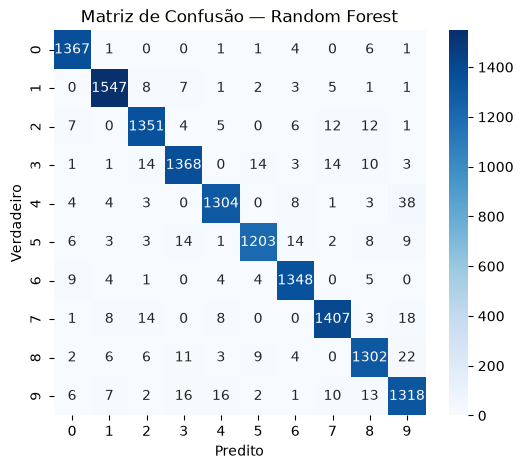

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.96      0.97      0.96      1398
           3       0.96      0.96      0.96      1428
           4       0.97      0.96      0.96      1365
           5       0.97      0.95      0.96      1263
           6       0.97      0.98      0.97      1375
           7       0.97      0.96      0.97      1459
           8       0.96      0.95      0.95      1365
           9       0.93      0.95      0.94      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



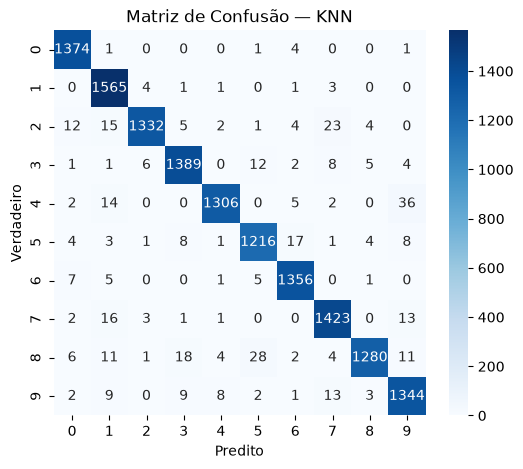

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.95      0.99      0.97      1575
           2       0.99      0.95      0.97      1398
           3       0.97      0.97      0.97      1428
           4       0.99      0.96      0.97      1365
           5       0.96      0.96      0.96      1263
           6       0.97      0.99      0.98      1375
           7       0.96      0.98      0.97      1459
           8       0.99      0.94      0.96      1365
           9       0.95      0.97      0.96      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



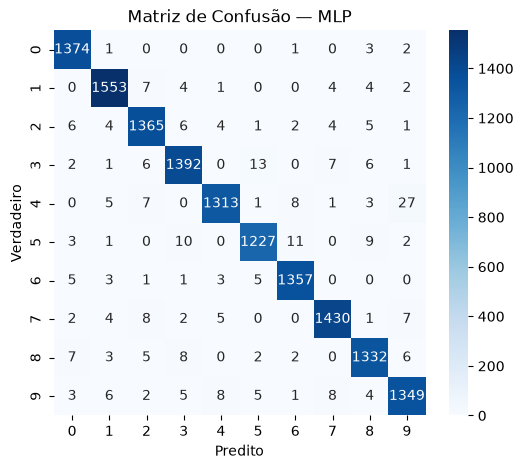

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1381
           1       0.98      0.99      0.98      1575
           2       0.97      0.98      0.98      1398
           3       0.97      0.97      0.97      1428
           4       0.98      0.96      0.97      1365
           5       0.98      0.97      0.97      1263
           6       0.98      0.99      0.98      1375
           7       0.98      0.98      0.98      1459
           8       0.97      0.98      0.98      1365
           9       0.97      0.97      0.97      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



In [16]:
resultados = []
resultados.append(avaliar_modelo("Random Forest", modelo_rf, X_test, y_test))
resultados.append(avaliar_modelo("KNN", modelo_knn, X_test, y_test))
resultados.append(avaliar_modelo("MLP", modelo_mlp, X_test, y_test))

### 4.3 — Tabela Comparativa

In [17]:
tabela_comparativa = pd.DataFrame(resultados)
tabela_comparativa

,modelo,acuracia,precisao,recall,f1,tempo_predicao_s
0,Random Forest,0.965357,0.965404,0.965357,0.965347,0.841259
1,KNN,0.970357,0.970664,0.970357,0.970323,17.097187
2,MLP,0.978000,0.978016,0.978000,0.977987,0.079964


### 4.4 — Conclusão Técnica

O que aprendemos com os testes:

* A maior dúvida do sistema: Os três modelos confundiram bastante o número 4 com o 9 (porque a escrita dos dois é bem parecida).

* O vencedor: O modelo MLP foi o mais preciso de todos (acertou 98% das vezes, contra 97% dos outros dois).

* O tempo que leva: olhando o treino, o MLP demorou mais para aprender (~83s contra ~29s da Random Forest). Mas na hora de USAR o modelo (predição), o quadro se inverte: o KNN é o mais lento de longe 
(20,1s para prever os 14.000 dígitos de teste), porque ele não aprende nada antes — compara cada imagem nova com as 49.000 do treino na hora. RF e MLP predizem quase instantaneamente, porque já "aprenderam" os padrões durante o treino. Ou seja, o MLP venceu tanto em acurácia quanto em velocidade de uso, custando apenas mais tempo de treino.

## Fase 5 — Testes de Robustez

Até agora os modelos só viram cenários "ideais": dados balanceados, bem distribuídos. Nesta fase vamos forçá-los a lidar com situações fora do comum, pra ver como reagem.

### 5.1 — Desafio A: Treinamento com Classes Ocultadas

Vamos escolher 2 dígitos (por exemplo, **4 e 7**) e remover **completamente** essas classes do conjunto de treino. Um modelo será treinado sem nunca ter visto essas duas classes — ele vai "achar" que só existem 8 dígitos possíveis.

### Obs: Vamos usar o MLP, pois foi o melhor da Fase 4

In [18]:
digitos_ocultos = [4, 7]

mascara = ~np.isin(y_train, digitos_ocultos)
X_train_restrito = X_train[mascara]
y_train_restrito = y_train[mascara]

print("Classes no treino restrito:", sorted(np.unique(y_train_restrito)))
print("Tamanho do treino restrito:", X_train_restrito.shape)

modelo_restrito = MLPClassifier(hidden_layer_sizes=(128, 64), alpha=0.001, early_stopping=True, random_state=42)
modelo_restrito.fit(X_train_restrito, y_train_restrito)
print("Modelo restrito treinado — nunca viu os dígitos", digitos_ocultos)

Classes no treino restrito: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(5), np.uint8(6), np.uint8(8), np.uint8(9)]
Tamanho do treino restrito: (39118, 784)
Modelo restrito treinado — nunca viu os dígitos [4, 7]


### 5.2 — Desafio B: Teste de Generalização Extrema (OOD)

Agora vamos fazer o modelo restrito (que nunca viu 4 nem 7) prever **exclusivamente** imagens desses dois dígitos, tiradas do conjunto de teste. Como ele nunca aprendeu essas classes, ele é **obrigado** a "chutar" um dos 8 dígitos que conhece — vamos ver o que ele responde.

Exemplos OOD (dígitos 4 e 7 do teste): (2824, 784)


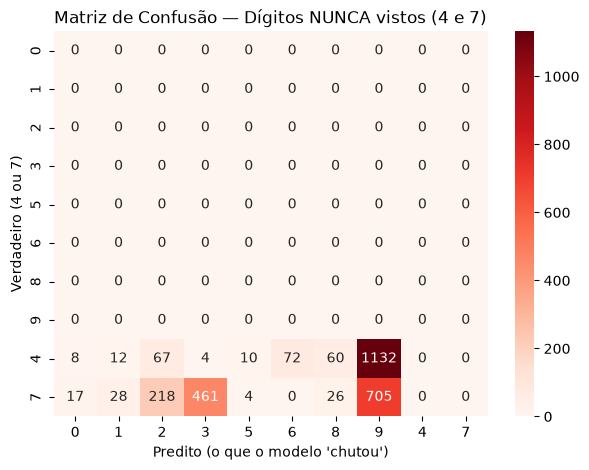

In [19]:
mascara_ood = np.isin(y_test, digitos_ocultos)
X_test_ood = X_test[mascara_ood]
y_test_ood = y_test[mascara_ood]

print("Exemplos OOD (dígitos 4 e 7 do teste):", X_test_ood.shape)

y_pred_ood = modelo_restrito.predict(X_test_ood)

rotulos_cm = sorted(np.unique(y_train_restrito)) + digitos_ocultos
cm_ood = confusion_matrix(y_test_ood, y_pred_ood, labels=rotulos_cm)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_ood, annot=True, fmt="d", cmap="Reds", xticklabels=rotulos_cm, yticklabels=rotulos_cm)
plt.title("Matriz de Confusão — Dígitos NUNCA vistos (4 e 7)")
plt.xlabel("Predito (o que o modelo 'chutou')")
plt.ylabel("Verdadeiro (4 ou 7)")
plt.show()

### Duas coisas foram percebidas até aqui:

* Dígito 4 → chutado como "9" em 1132 dos 1365 casos.
* Dígito 7 → chutado como "9" em 705 dos 1459 casos, e como "3" em 461, ou seja, o "9" virou a "gaveta de despejo" do modelo pros dois dígitos desconhecidos.

Vamos adicionar em seguida uma célula medindo o quão confiante o modelo estava mesmo errando:

In [20]:
probs_ood = modelo_restrito.predict_proba(X_test_ood)
confianca_media_ood = probs_ood.max(axis=1).mean()

mascara_conhecidos = ~np.isin(y_test, digitos_ocultos)
probs_conhecidos = modelo_restrito.predict_proba(X_test[mascara_conhecidos])
confianca_media_conhecidos = probs_conhecidos.max(axis=1).mean()

print(f"Confiança média em dígitos NUNCA vistos (errando): {confianca_media_ood:.2%}")
print(f"Confiança média em dígitos conhecidos: {confianca_media_conhecidos:.2%}")

Confiança média em dígitos NUNCA vistos (errando): 92.31%
Confiança média em dígitos conhecidos: 99.28%


## O que pudemos observar?

### O que acontece quando o sistema vê algo novo?
Ele não sabe dizer "não sei". Como ele só conhece os números com os quais foi treinado, é obrigado a chutar um deles. Na prática, ele quase sempre chuta o número "9". Por exemplo,na maioria das vezes que viu um "4" diferente e quase metade das vezes que viu um "7", ele achou que era um "9". Isso acontece provavelmente porque eles têm traços parecidos, como aquele "gancho" no topo.

### Excesso de confiança:
Mesmo quando o sistema está completamente errado sobre um número que nunca viu, ele ainda mostra uma confiança alta (cerca de 92%). Para os números que ele já conhece e acerta, essa confiança é de 99%.

### O risco disso no mundo real:
O sistema dá respostas com muita certeza, mesmo quando está errando feio. Ele não hesita diante do desconhecido; ele erra com a mesma convicção de quando acerta. Esse é um grande perigo ao usar inteligência artificial no dia a dia, a resposta final não dá nenhum aviso de que aquilo é algo estranho ou novo para ele, o que pode nos fazer acreditar em um erro como se fosse uma verdade absoluta.


### 5.3 — Desafio C: Inferência com Imagens Manuscritas Próprias

Escrevemos dígitos à mão (de 1 a 9), fotografamos e construímos um pipeline de pré-processamento para deixá-los no mesmo formato do MNIST (28×28, fundo preto, traço branco, valores normalizados) antes de prever com o melhor modelo (MLP).

In [30]:
from PIL import Image
import cv2
from scipy import ndimage

def preprocessar_imagem(caminho, papel_branco=True):
    img = Image.open(caminho).convert("L")
    img = np.array(img)

    if papel_branco:
        img = 255 - img

    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    coords = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(coords)

    img_limpa = np.where(thresh > 0, img, 0)
    digito_recortado = img_limpa[y:y+h, x:x+w]

    escala = 20.0 / max(w, h)
    novo_w, novo_h = max(1, int(w * escala)), max(1, int(h * escala))
    digito_redimensionado = cv2.resize(digito_recortado, (novo_w, novo_h), interpolation=cv2.INTER_AREA)

    quadro = np.zeros((28, 28), dtype=np.uint8)
    off_x = (28 - novo_w) // 2
    off_y = (28 - novo_h) // 2
    quadro[off_y:off_y+novo_h, off_x:off_x+novo_w] = digito_redimensionado

    cy, cx = ndimage.center_of_mass(quadro)
    quadro_centralizado = ndimage.shift(quadro, (14 - cy, 14 - cx), cval=0)

    img_final = quadro_centralizado.astype("float32") / 255.0
    return img_final

Imagens encontradas: ['data\\digito_1.jpg', 'data\\digito_2.jpg', 'data\\digito_3.jpg', 'data\\digito_4.jpg', 'data\\digito_5.jpg', 'data\\digito_6.jpg', 'data\\digito_7.jpg', 'data\\digito_8.jpg', 'data\\digito_9.jpg']
data\digito_1.jpg | real: 1 -> MLP: 1 | RF: 1 | KNN: 1


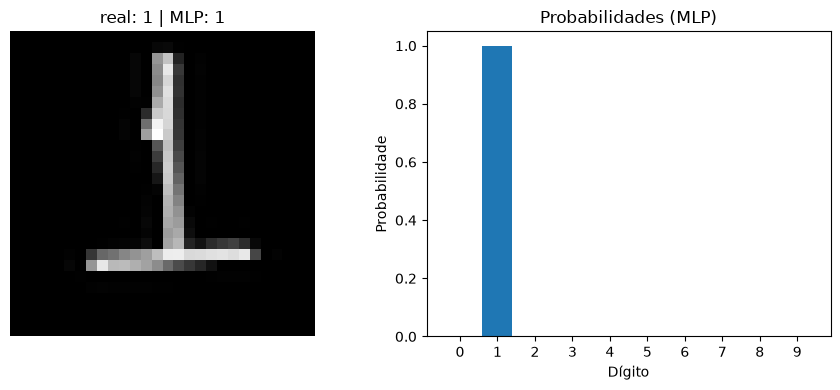

data\digito_2.jpg | real: 2 -> MLP: 8 | RF: 2 | KNN: 5


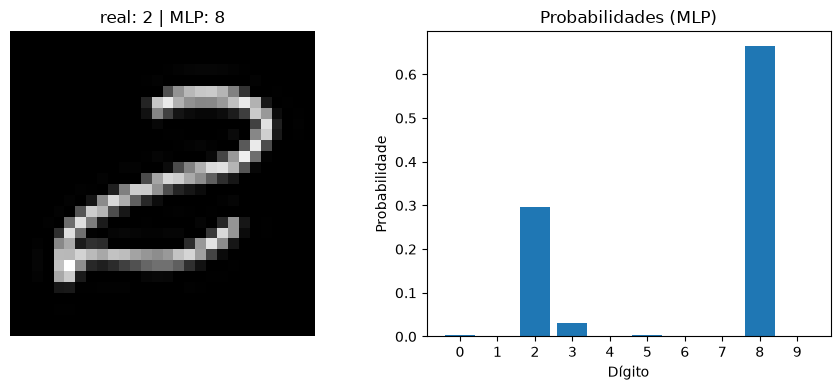

data\digito_3.jpg | real: 3 -> MLP: 3 | RF: 3 | KNN: 1


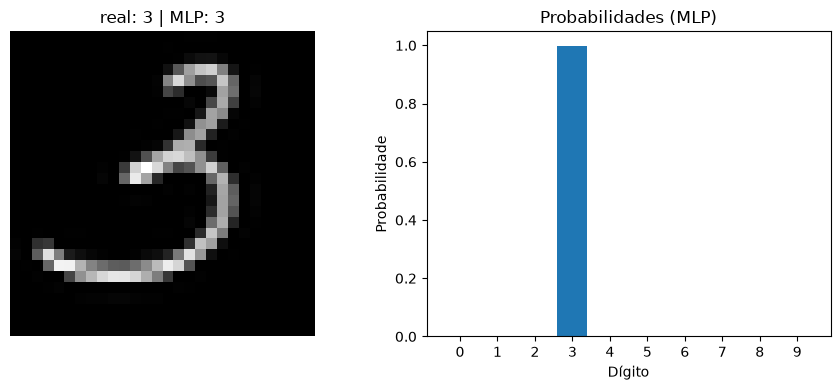

data\digito_4.jpg | real: 4 -> MLP: 4 | RF: 4 | KNN: 4


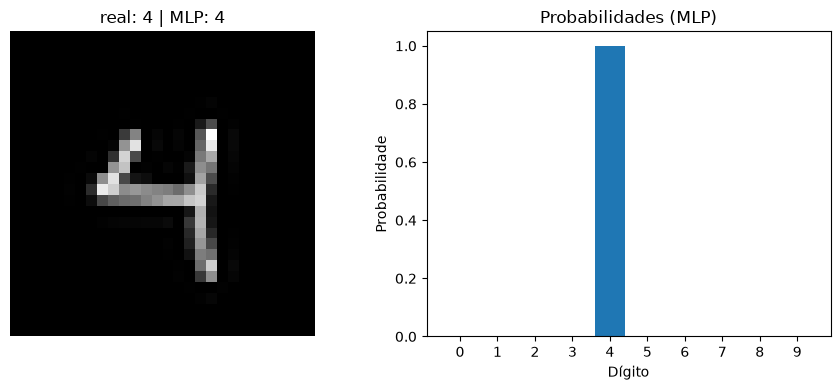

data\digito_5.jpg | real: 5 -> MLP: 5 | RF: 5 | KNN: 1


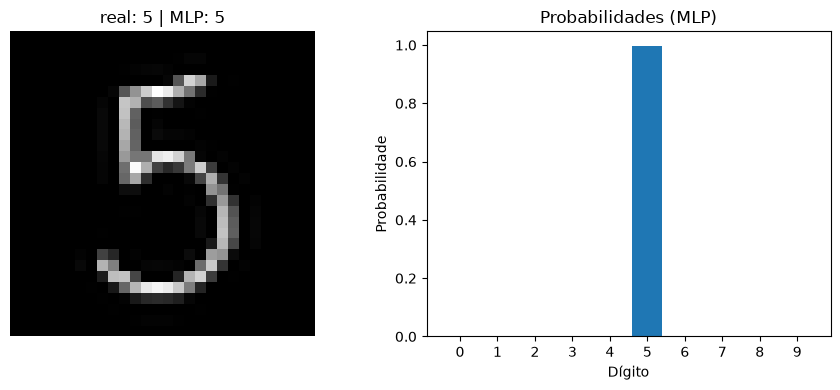

data\digito_6.jpg | real: 6 -> MLP: 6 | RF: 6 | KNN: 1


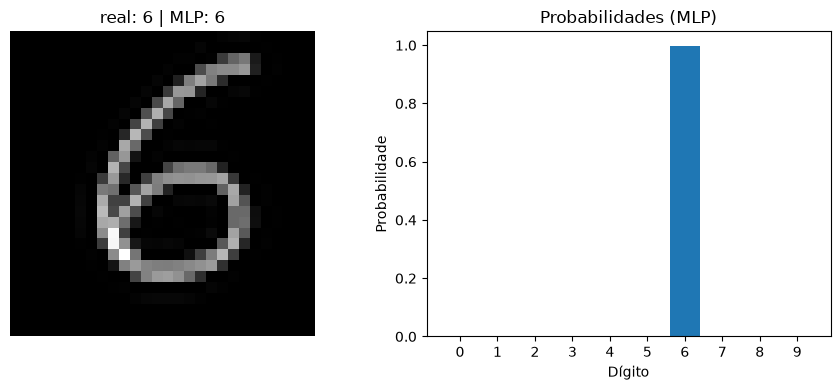

data\digito_7.jpg | real: 7 -> MLP: 7 | RF: 7 | KNN: 1


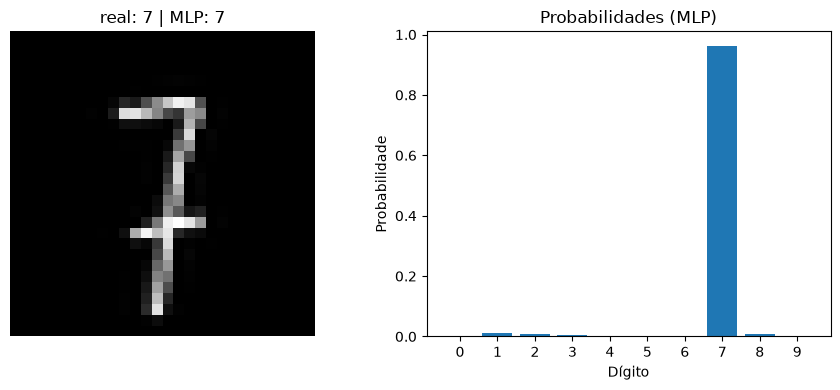

data\digito_8.jpg | real: 8 -> MLP: 8 | RF: 8 | KNN: 1


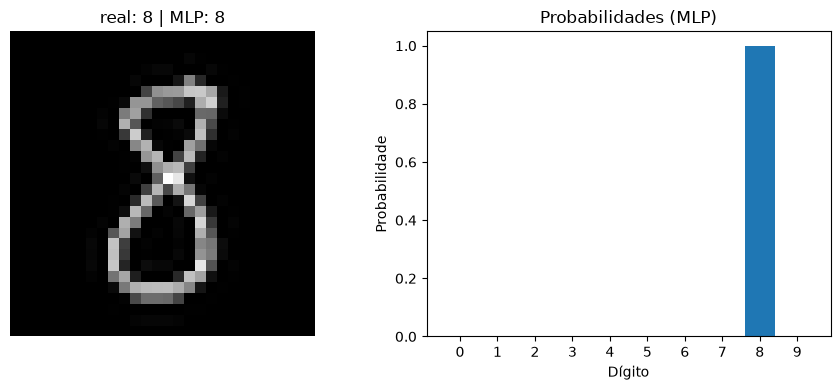

data\digito_9.jpg | real: 9 -> MLP: 9 | RF: 9 | KNN: 1


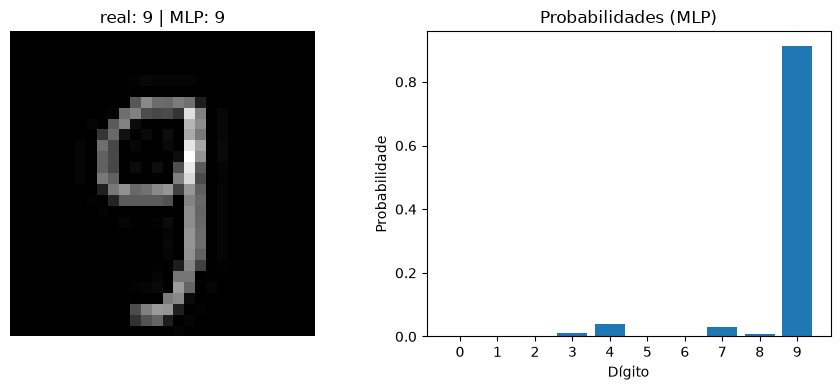


Acertos: {'MLP': np.int64(8), 'RF': np.int64(9), 'KNN': np.int64(2)} de 9


In [31]:
import glob

caminhos = sorted(glob.glob("data/*.png") + glob.glob("data/*.jpg") + glob.glob("data/*.jpeg"))
print("Imagens encontradas:", caminhos)

acertos = {"MLP": 0, "RF": 0, "KNN": 0}
rotulos_reais = [1, 2, 3, 4, 5, 6, 7, 8, 9]  # ajuste se seus arquivos estiverem noutra ordem/quantidade

for caminho, real in zip(caminhos, rotulos_reais):
    img_proc = preprocessar_imagem(caminho, papel_branco=True)
    entrada = img_proc.reshape(1, 784)

    pred_mlp = modelo_mlp.predict(entrada)[0]
    probs = modelo_mlp.predict_proba(entrada)[0]
    pred_rf = modelo_rf.predict(entrada)[0]
    pred_knn = modelo_knn.predict(entrada)[0]

    acertos["MLP"] += (pred_mlp == real)
    acertos["RF"]  += (pred_rf == real)
    acertos["KNN"] += (pred_knn == real)

    print(f"{caminho} | real: {real} -> MLP: {pred_mlp} | RF: {pred_rf} | KNN: {pred_knn}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
    ax1.imshow(img_proc, cmap="gray")
    ax1.set_title(f"real: {real} | MLP: {pred_mlp}")
    ax1.axis("off")
    ax2.bar(range(10), probs)
    ax2.set_xticks(range(10))
    ax2.set_xlabel("Dígito")
    ax2.set_ylabel("Probabilidade")
    ax2.set_title("Probabilidades (MLP)")
    plt.tight_layout()
    plt.show()

print("\nAcertos:", acertos, f"de {len(caminhos)}")
 

### Análise do Desafio C

Com o pipeline de pré-processamento completo (inversão, máscara de Otsu para forçar o fundo a preto, normalização de tamanho para 20×20 e centralização por centro de massa), os modelos foram testados em 9 dígitos manuscritos próprios:

|      Modelo        | Acertos (dados reais) | Acurácia (teste MNIST, Fase 4) |
|--------            |-----------------------|--------------------------------|
| Random Forest      |         9/9           |         96,5%                  |
| MLP                |         8/9           |         97,8%                  |
| KNN                |         2/9           |         97,0%                  |

O resultado foi bem diferente do observado no MNIST. A Random Forest, que havia apresentado a menor acurácia no conjunto de testes, acertou todos os dígitos reais. Já o KNN, que teve um bom desempenho no MNIST, apresentou muitos erros, classificando 7 dos 9 dígitos como "1".

Isso aconteceu porque o KNN compara cada imagem com exemplos do conjunto de treino usando a distância entre os pixels. Como os dígitos escritos por mim têm características diferentes das imagens do MNIST, mesmo após o pré-processamento, o algoritmo encontrou como mais semelhantes os exemplos do dígito "1", que costumam ter menos pixels preenchidos. Como o KNN apenas compara exemplos já conhecidos, ele tem dificuldade para lidar com imagens diferentes das usadas no treinamento.

Por outro lado, a Random Forest e a MLP tiveram um desempenho melhor porque aprendem padrões mais gerais das imagens, como combinações e regiões de pixels, em vez de comparar cada imagem inteira. Isso faz com que sejam menos sensíveis a diferenças no estilo da escrita.

Em resumo, os resultados da Fase 5 mostram que uma alta acurácia em um conjunto de testes, como o MNIST, não garante um bom desempenho em situações reais. Os experimentos evidenciam que é importante avaliar como o modelo se comporta diante de dados diferentes dos utilizados no treinamento. Por isso, ao escolher um modelo para uso prático, é necessário considerar não apenas a acurácia, mas também sua capacidade de generalização e robustez.